
----- STUDENT REPORT -----

🎯 Group: Under Performer

⚠️ Alerts:
- Low study time
- Low attendance
- Average focus

🔥 Burnout Risk: Medium

📊 Score: 63.44
🚨 Risk Level: Medium

💡 Recommendations:
- Try using Pomodoro technique.
- Attend classes regularly.
- Improve consistency and minimize interruptions.



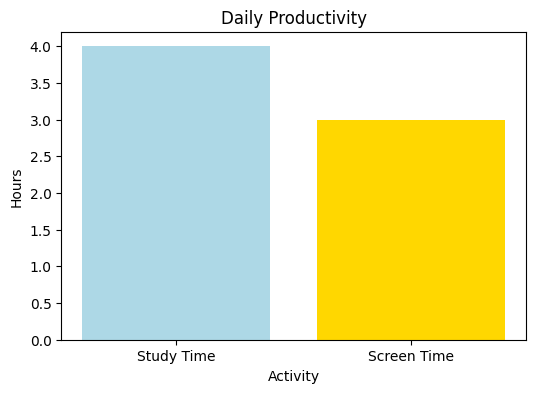

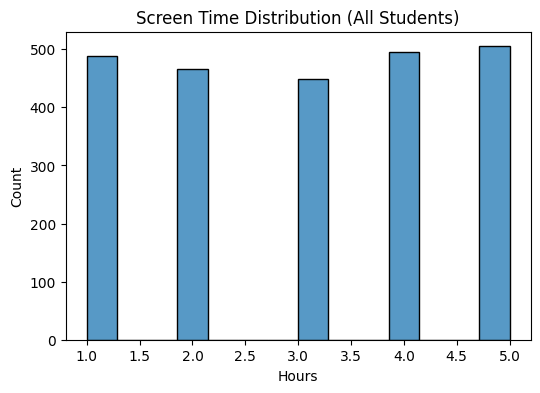

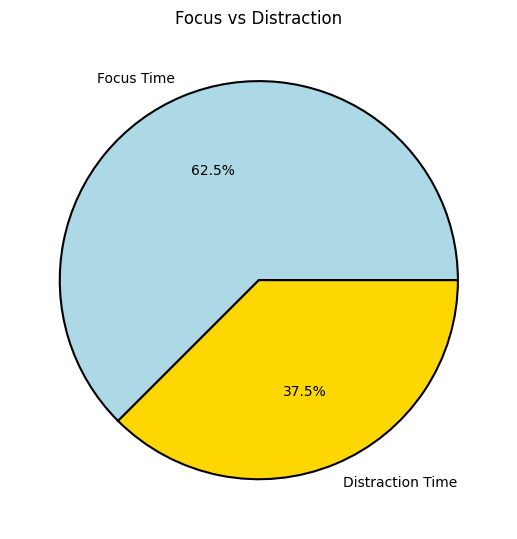

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns

# ---------- LOAD & PREPROCESS ----------
df = pd.read_csv('student_performance_large.csv')

df = df.dropna(subset=['Gender','Result','Extra_Activities','Study_Hours','Attendance','Internet_Usage','Marks'])

df['Parental_Education'] = df['Parental_Education'].fillna('Unknown')
df['Age'] = df['Age'].fillna(df['Age'].mean())
df['Study_Hours'] = df['Study_Hours'].fillna(df['Study_Hours'].mean())
df['Sleep_Hours'] = df['Sleep_Hours'].fillna(df['Sleep_Hours'].mean())

df['Internet_Usage'] = df['Internet_Usage'].replace(' ', np.nan)
df['Internet_Usage'] = pd.to_numeric(df['Internet_Usage'], errors='coerce')
df['Internet_Usage'] = df['Internet_Usage'].fillna(df['Internet_Usage'].mean())

# ---------- ENCODING ----------
le = LabelEncoder()
df['Gender_Encoded'] = le.fit_transform(df['Gender'])
df['Extra_Activities_Encoded'] = le.fit_transform(df['Extra_Activities'])
df['Result_Encoded'] = le.fit_transform(df['Result'])

# ---------- FEATURE SELECTION ----------
df_copy = df[['Study_Hours', 'Attendance', 'Sleep_Hours', 'Internet_Usage']].copy()

# ---------- SCALING ----------
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_copy)

# ---------- KMEANS ----------
kmeans = KMeans(n_clusters=2, random_state=42, n_init=20)
df_copy['Cluster'] = kmeans.fit_predict(X_scaled)

# ---------- CLUSTER NAMING ----------
cluster_means = df_copy.groupby('Cluster')['Attendance'].mean().sort_values()

group_names = {
    cluster_means.index[0]: 'Under Performer',
    cluster_means.index[1]: 'Good Performer'
}

df_copy['Group'] = df_copy['Cluster'].map(group_names)

# ---------- GROUP STATS (FIX) ----------
group_stats = round(df_copy.groupby('Group').mean(), 2)

# ---------- LINEAR REGRESSION ----------
X = df[['Study_Hours', 'Attendance', 'Internet_Usage']]
y = df['Marks']

model_score = LinearRegression()
model_score.fit(X, y)

# ---------- MAIN FUNCTION ----------
def analyze(data):

    hours = data.get("study")
    attendance = data.get("attendance")
    net_usage = data.get("screen")
    active_tab = data.get("active")
    time_on_site = data.get("time", hours)
    sleep = data.get("sleep", 6)

    user_df = pd.DataFrame([{
        'Study_Hours': hours,
        'Attendance': attendance,
        'Sleep_Hours': sleep,
        'Internet_Usage': net_usage,
    }])

    user_scaled = scaler.transform(user_df)
    group_num = kmeans.predict(user_scaled)[0]
    group = group_names[group_num]

    avg_hours = group_stats.loc[group, 'Study_Hours']
    avg_attendance = group_stats.loc[group, 'Attendance']
    avg_net_usage = group_stats.loc[group, 'Internet_Usage']

    # Focus Ratio :-
    study_time = time_on_site
    screen_time = net_usage if net_usage != 0 else 1
    focus_ratio = study_time / screen_time

    alerts = []
    recommendations = []

    if hours < avg_hours:
        alerts.append("Low study time")
        recommendations.append("Try using Pomodoro technique.")

    if attendance < avg_attendance:
        alerts.append("Low attendance")
        recommendations.append("Attend classes regularly.")

    if net_usage > avg_net_usage:
        alerts.append("High screen time")
        recommendations.append("Reduce unnecessary screen usage.")

    if focus_ratio < 1:
     alerts.append("Poor focus")
     recommendations.append("Reduce distractions and avoid multitasking.")

    elif focus_ratio < 2:
     alerts.append("Average focus")
     recommendations.append("Improve consistency and minimize interruptions.")

    else:
     recommendations.append("Great focus, keep it up!")

    burnout = "Low"

    if hours < 3 and net_usage > 6:
        burnout = "High"
    elif sleep < 5:
        burnout = "Medium"

    values_df = pd.DataFrame([[hours, attendance, net_usage]],
                             columns=['Study_Hours', 'Attendance', 'Internet_Usage'])

    score = round(model_score.predict(values_df)[0], 2)

    if score < 60:
        risk = "High"
    elif score < 80:
        risk = "Medium"
    else:
        risk = "Low"

    return {
        "group": group,
        "alerts": alerts,
        "burnout_risk": burnout,
        "score": score,
        "risk": risk,
        "recommendations": recommendations
    }


def format_output(result):
    alerts_text = "\n- ".join(result['alerts']) if result['alerts'] else "None"
    rec_text = "\n- ".join(result['recommendations']) if result['recommendations'] else "None"

    return f"""
----- STUDENT REPORT -----

🎯 Group: {result['group']}

⚠️ Alerts:
- {alerts_text}

🔥 Burnout Risk: {result['burnout_risk']}

📊 Score: {float(result['score']):.2f}
🚨 Risk Level: {result['risk']}

💡 Recommendations:
- {rec_text}
"""




# ---------- TEST ----------
if __name__ == "__main__":
    data = {
        "study": 4,
        "attendance": 60,
        "screen": 3,
        "sleep": 4,
        "time" : 5
    }

    result = format_output(analyze(data))
    print(result)

def visualize(data):
    hours = data.get("study")
    net_usage = data.get("screen")
    time_on_site = data.get("time", hours)

    # ---------- 1. Daily Productivity ----------
    plt.figure(figsize=(6,4))
    productivity = [hours, net_usage]
    labels = ['Study Time', 'Screen Time']
    plt.bar(labels, productivity, label='Daily Productivity', color=['lightblue', 'gold'])
    plt.title("Daily Productivity")
    plt.xlabel("Activity")
    plt.ylabel("Hours")
    plt.show()

    # ---------- 2. Screen Time Distribution ----------
    plt.figure(figsize=(6,4))
    sns.histplot(df['Internet_Usage'])
    plt.title("Screen Time Distribution (All Students)")
    plt.xlabel("Hours")
    plt.ylabel("Count")
    plt.show()

    # ---------- 3. Focus vs Distraction ----------
    plt.figure(figsize=(6,5.5))
    focus = time_on_site
    distraction = net_usage if net_usage != 0 else 1

    plt.pie([focus, distraction],
            labels=['Focus Time', 'Distraction Time'],
            autopct='%1.1f%%', colors=['lightblue', 'gold'],
            wedgeprops={'edgecolor': 'black', 'linewidth': 1.5})

    plt.title("Focus vs Distraction")
    plt.tight_layout()
    plt.show()

visualize(data)


